In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binom

np.random.seed(42)
sns.set_style("whitegrid")

In [15]:
N = 1000000
step = 100


x = np.random.uniform(-1, 1, N)
y = np.random.uniform(-1, 1, N)
inside = x**2 + y**2 <= 1


pi_estimate = (inside.sum() / N) * 4
print(f"Estimated value of π: {pi_estimate:.6f}")
print(f"True value of π:      {np.pi:.6f}")

Estimated value of π: 3.139892
True value of π:      3.141593


In [16]:
running_pi = [4 * np.sum(inside[:i])/i for i in range(step, N+1, step)]

eps = 0.01
running_pi_arr = np.array(running_pi)
within_band = np.abs(running_pi_arr - np.pi) <= eps

stable_index = None
for i in range(len(within_band)):
    if np.all(within_band[i:]):
        stable_index = (i+1) * step
        break

print(f"First sample where π estimate stabilizes within ±0.01: {stable_index}")


First sample where π estimate stabilizes within ±0.01: 48400


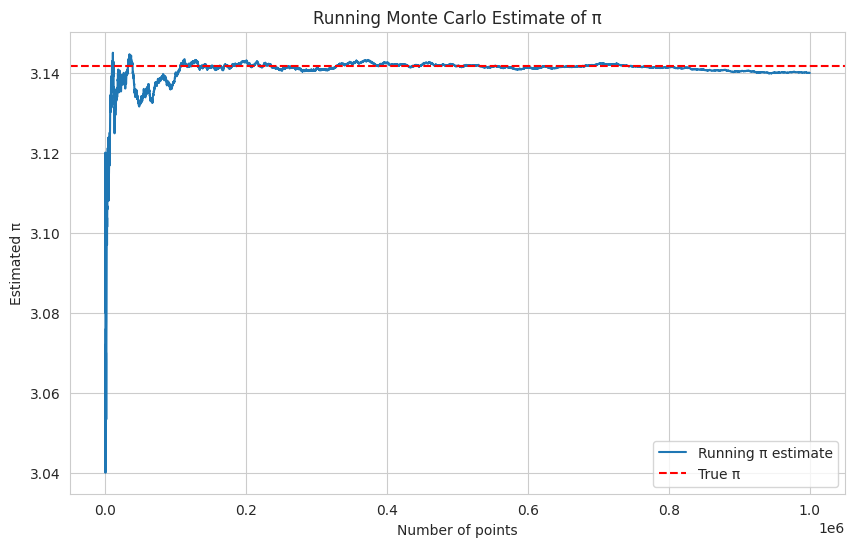

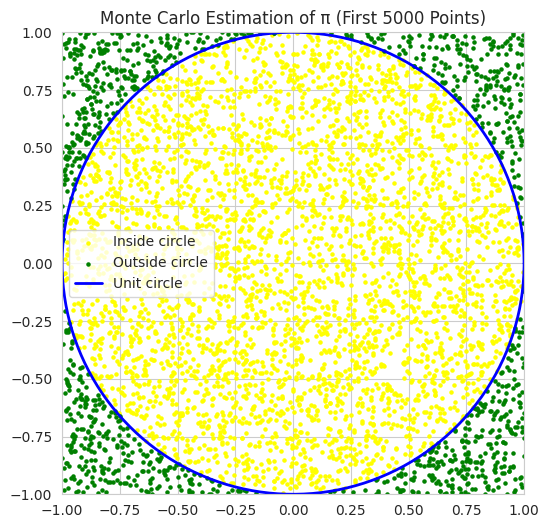

In [17]:
plt.figure(figsize=(10,6))
plt.plot(range(step, N+1, step), running_pi, label="Running π estimate")
plt.axhline(np.pi, color='red', linestyle='--', label="True π")
plt.xlabel("Number of points")
plt.ylabel("Estimated π")
plt.title("Running Monte Carlo Estimate of π")
plt.legend()
plt.show()


x_plot = x[:5000]
y_plot = y[:5000]
inside_plot = inside[:5000]

plt.figure(figsize=(6,6))
plt.scatter(x_plot[inside_plot], y_plot[inside_plot], s=5, color='yellow', label="Inside circle")
plt.scatter(x_plot[~inside_plot], y_plot[~inside_plot], s=5, color='green', label="Outside circle")

theta = np.linspace(0, 2*np.pi, 500)
circle_x = np.cos(theta)
circle_y = np.sin(theta)
plt.plot(circle_x, circle_y, color='blue', linewidth=2, label="Unit circle")

plt.gca().set_aspect('equal')
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.title("Monte Carlo Estimation of π (First 5000 Points)")
plt.legend()
plt.show()

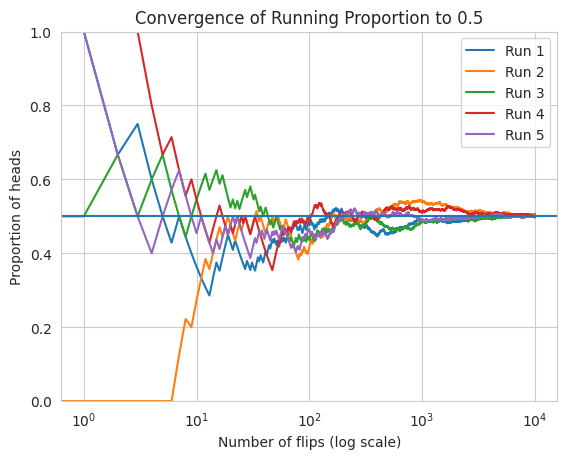

In [18]:
N = 10000
runs = 5

for i in range(runs):
    coin = np.random.choice([0, 1], size=N)
    cumdrop = np.cumsum(coin) / np.arange(1, N+1)
    
    plt.plot(cumdrop, label=f'Run {i+1}')

eps = 0.01
coin = np.random.choice([0,1], size=N)
cumprop = np.cumsum(coin) / np.arange(1, N+1)

within_band = np.abs(cumprop - 0.5) <= eps

stable_index = None
for i in range(N):
    if np.all(within_band[i:]):
        stable_index = i + 1 
        break

plt.axhline(0.5)

plt.xscale('log')
plt.ylim([0,1])
plt.xlabel("Number of flips (log scale)")
plt.ylabel("Proportion of heads")
plt.title("Convergence of Running Proportion to 0.5")
plt.legend()

plt.show()

Expected number of defects per batch (simulation): 1.5006
Estimated P(0 defects): 0.2148
Estimated P(3 defects): 0.1257


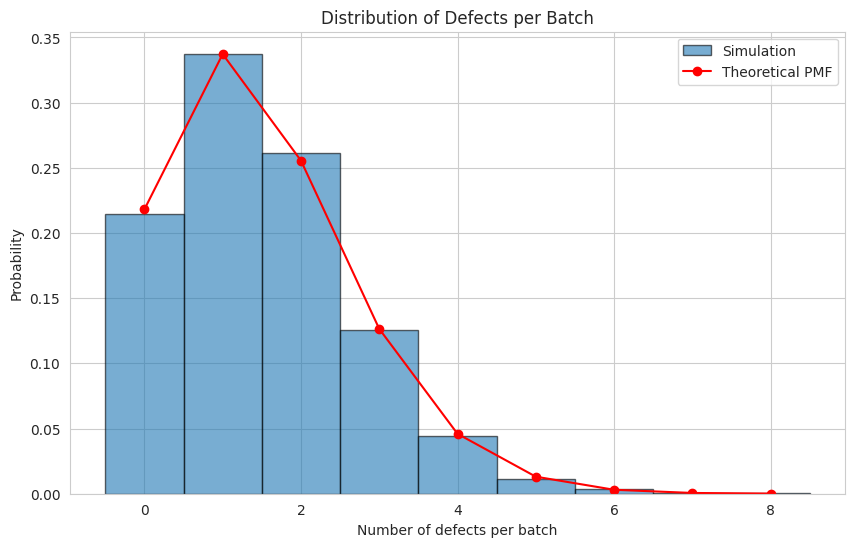

In [19]:
B = 10000
n = 50
all_defects = []
for i in range(B):
    records = np.random.binomial(1, 0.03, size=n)
    defects = np.sum(records)
    all_defects.append(defects)


all_defects = np.array(all_defects)
p0_sim = np.sum(all_defects == 0) / B
p3_sim = np.sum(all_defects == 3) / B
print(f"Expected number of defects per batch (simulation): {np.mean(all_defects)}")
print(f"Estimated P(0 defects): {p0_sim:.4f}")
print(f"Estimated P(3 defects): {p3_sim:.4f}")



plt.figure(figsize=(10,6))
plt.hist(all_defects, bins=np.arange(all_defects.max()+2)-0.5, 
         density=True, edgecolor='black', alpha=0.6, label='Simulation')

k = np.arange(all_defects.max()+1)
plt.plot(k, binom.pmf(k, n, 0.03), 'o-', color='red', label='Theoretical PMF')

plt.xlabel('Number of defects per batch')
plt.ylabel('Probability')
plt.title('Distribution of Defects per Batch')
plt.legend()
plt.show()

